In [1]:
# --- Imports (replace the TF ones) ---
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from herbs_detection.model import predict, predict_top3, predict_set

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
PROJECT_ROOT = Path("/home/ed_st/code/anteecip/computer_vision/plant_detect")
ALL_IMAGES_DIR = PROJECT_ROOT / "backend/data/all_images"
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS_FROZEN = 10
EPOCHS_FINE = 20

# --- Load labels ---
# labels = pd.read_csv(PROJECT_ROOT / "data/labels.csv")
# # match images in all_images/ by basename of the original path
# labels["basename"] = labels["filename"].apply(lambda f: Path(f).name)
# print(labels["name"].value_counts())
# print(f"\nTotal: {len(labels)} images")

In [3]:
import os
import re
import pandas as pd

base_dir = "../backend/data/all_images"

rows = []
for fichier in sorted(os.listdir(base_dir)):
    if not fichier.lower().endswith(".jpg"):
        continue

    # Supprime _x.jpg final pour extraire le label
    label = re.sub(r'_\d+\.jpg$', '', fichier, flags=re.IGNORECASE)

    rows.append({
        "label" : label,
        "path"  : fichier
    })

labels = pd.DataFrame(rows, columns=["label", "path"])

print(f"{len(labels)} images | {labels['label'].nunique()} classes")
print(labels.head(10))

260 images | 13 classes
             label                    path
0  Apple_Black_rot   Apple_Black_rot_1.jpg
1  Apple_Black_rot  Apple_Black_rot_10.jpg
2  Apple_Black_rot  Apple_Black_rot_11.jpg
3  Apple_Black_rot  Apple_Black_rot_12.jpg
4  Apple_Black_rot  Apple_Black_rot_13.jpg
5  Apple_Black_rot  Apple_Black_rot_14.jpg
6  Apple_Black_rot  Apple_Black_rot_15.jpg
7  Apple_Black_rot  Apple_Black_rot_16.jpg
8  Apple_Black_rot  Apple_Black_rot_17.jpg
9  Apple_Black_rot  Apple_Black_rot_18.jpg


In [4]:
labels

,label,path
0,Apple_Black_rot,Apple_Black_rot_1.jpg
1,Apple_Black_rot,Apple_Black_rot_10.jpg
2,Apple_Black_rot,Apple_Black_rot_11.jpg
3,Apple_Black_rot,Apple_Black_rot_12.jpg
4,Apple_Black_rot,Apple_Black_rot_13.jpg
...,...,...
255,Tomato_mosaic_virus,Tomato_mosaic_virus_5.jpg
256,Tomato_mosaic_virus,Tomato_mosaic_virus_6.jpg
257,Tomato_mosaic_virus,Tomato_mosaic_virus_7.jpg
258,Tomato_mosaic_virus,Tomato_mosaic_virus_8.jpg


In [5]:
# --- Load images from all_images/ as numpy arrays ---
X, y = [], []
missing = []

for _, row in labels.iterrows():
    img_path = ALL_IMAGES_DIR / row["path"]
    # print(f"Loading {img_path}")
    if not img_path.exists():
        missing.append(row["path"])
        continue
    img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    X.append(np.array(img))
    y.append(row["label"])

if missing:
    print(f"Warning: {len(missing)} images not found in all_images/")

X = np.array(X, dtype=np.float32) / 255.0   # shape: (N, 256, 256, 3), normalized to [0, 1]
y = np.array(y)

le = LabelEncoder()
y_enc = le.fit_transform(y)                  # integer labels
NUM_CLASSES = len(le.classes_)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y_enc.shape}")
print(f"Classes ({NUM_CLASSES}): {le.classes_}")




X shape: (260, 256, 256, 3)
y shape: (260,)
Classes (13): ['Apple_Black_rot' 'Apple_Cedar_apple_rust' 'Apple_scab'
 'Tomato_Bacterial_spot' 'Tomato_Early_blight' 'Tomato_Late_blight'
 'Tomato_Leaf_Mold' 'Tomato_Septoria_leaf_spot' 'Tomato_Spider_mites'
 'Tomato_Target_Spot' 'Tomato_Yellow_Leaf_Curl_Virus' 'Tomato_healthy'
 'Tomato_mosaic_virus']


In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

class PlantDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X          # (N, 224, 224, 3) float32 in [0,1]
        self.y = y
        self.augment = augment
        self.normalize = transforms.Normalize([0.485, 0.456, 0.406],
                                              [0.229, 0.224, 0.225])
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]) if augment else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx]).permute(2, 0, 1)  # (3, H, W)
        if self.aug:
            img = self.aug(img)
        img = self.normalize(img)
        return img, int(self.y[idx])


In [15]:
# --- Dataset ---

from sklearn.model_selection import train_test_split

idx = np.arange(len(X))
idx_train, idx_test = train_test_split(idx, test_size=0.15, stratify=y_enc, random_state=42)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.15, stratify=y_enc[idx_train], random_state=42)

train_loader = DataLoader(PlantDataset(X[idx_train], y_enc[idx_train], augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(PlantDataset(X[idx_val],   y_enc[idx_val]),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(PlantDataset(X[idx_test],  y_enc[idx_test]),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



In [16]:
# --- Model: ResNet18 pretrained ---
model = models.resnet18(weights="IMAGENET1K_V1")

# Phase 1: freeze backbone, replace head
for p in model.parameters():
    p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)  # only head is trainable

model = model.to(DEVICE)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct = 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labs in loader:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labs)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(imgs)
            correct    += (out.argmax(1) == labs).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

# --- Phase 1: head only ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

print("Phase 1 — frozen backbone")
for epoch in range(EPOCHS_FROZEN):
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader,   train=False)
    print(f"Epoch {epoch+1:02d} | train loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}")


Phase 1 — frozen backbone
Epoch 01 | train loss 2.644 acc 0.053 | val loss 2.633 acc 0.029
Epoch 02 | train loss 2.366 acc 0.241 | val loss 2.438 acc 0.118
Epoch 03 | train loss 2.120 acc 0.369 | val loss 2.218 acc 0.235
Epoch 04 | train loss 1.921 acc 0.561 | val loss 2.029 acc 0.471
Epoch 05 | train loss 1.728 acc 0.674 | val loss 1.891 acc 0.500
Epoch 06 | train loss 1.539 acc 0.727 | val loss 1.765 acc 0.588
Epoch 07 | train loss 1.403 acc 0.722 | val loss 1.648 acc 0.647
Epoch 08 | train loss 1.283 acc 0.818 | val loss 1.552 acc 0.706
Epoch 09 | train loss 1.174 acc 0.845 | val loss 1.473 acc 0.676
Epoch 10 | train loss 1.068 acc 0.898 | val loss 1.398 acc 0.765


In [17]:
# --- Phase 2: unfreeze all layers, fine-tune with low Loss Rate ---
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val, patience_cnt, best_state = 0, 0, None
print("\nPhase 2 — fine-tuning")
for epoch in range(EPOCHS_FINE):
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader,   train=False)
    scheduler.step(vl)
    print(f"Epoch {epoch+1:02d} | train loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}")
    if va > best_val:
        best_val = va; best_state = {k: v.clone() for k, v in model.state_dict().items()}; patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= 5:
            print("Early stopping"); break

model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_val:.3f}")



Phase 2 — fine-tuning
Epoch 01 | train loss 0.936 acc 0.856 | val loss 0.918 acc 0.853
Epoch 02 | train loss 0.375 acc 0.973 | val loss 0.647 acc 0.882
Epoch 03 | train loss 0.165 acc 0.995 | val loss 0.536 acc 0.853
Epoch 04 | train loss 0.093 acc 0.995 | val loss 0.530 acc 0.824
Epoch 05 | train loss 0.048 acc 1.000 | val loss 0.533 acc 0.853
Epoch 06 | train loss 0.038 acc 1.000 | val loss 0.511 acc 0.853
Epoch 07 | train loss 0.022 acc 1.000 | val loss 0.504 acc 0.853
Early stopping

Best val accuracy: 0.882


                               precision    recall  f1-score   support

              Apple_Black_rot       0.75      1.00      0.86         3
       Apple_Cedar_apple_rust       1.00      1.00      1.00         3
                   Apple_scab       1.00      0.67      0.80         3
        Tomato_Bacterial_spot       0.60      1.00      0.75         3
          Tomato_Early_blight       0.60      1.00      0.75         3
           Tomato_Late_blight       1.00      0.67      0.80         3
             Tomato_Leaf_Mold       1.00      0.33      0.50         3
    Tomato_Septoria_leaf_spot       1.00      0.67      0.80         3
          Tomato_Spider_mites       0.60      1.00      0.75         3
           Tomato_Target_Spot       0.75      1.00      0.86         3
Tomato_Yellow_Leaf_Curl_Virus       1.00      1.00      1.00         3
               Tomato_healthy       1.00      0.33      0.50         3
          Tomato_mosaic_virus       1.00      0.67      0.80         3

    

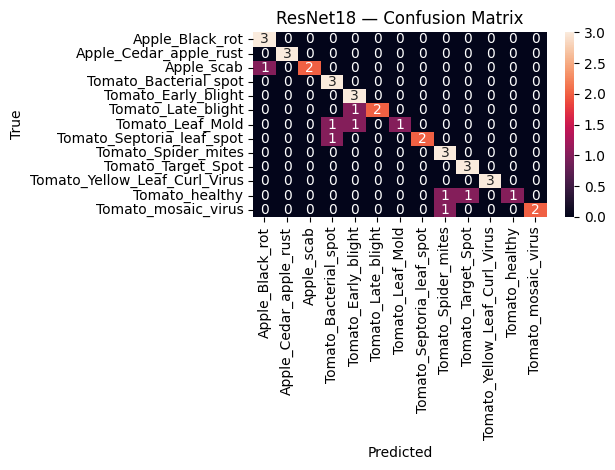

In [18]:
# --- Evaluation ---
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labs in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().tolist()
        y_pred.extend(preds)
        y_true.extend(labs.tolist())

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("ResNet18 — Confusion Matrix")
plt.tight_layout(); plt.show()


In [19]:
import torch
from sklearn.preprocessing import LabelEncoder
import pickle

save_dir = PROJECT_ROOT / "backend/app/models"
save_dir.mkdir(parents=True, exist_ok=True)

# Save model weights (equivalent to model.save_weights() in Keras)
torch.save(model.state_dict(), save_dir / "resnet18_plants.pt")

# Save the LabelEncoder too — you need it to decode predictions back to species names
with open(save_dir / "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model saved.")


Model saved.


In [ ]:
# Try it

import importlib
import torch

# Vider la variable model de la mémoire
# del model
# torch.cuda.empty_cache()   # vide aussi le cache GPU si cuda
# Recharger depuis le disque
# model = torch.load(save_dir / "resnet18_plants.pt", map_location=DEVICE)
# model.eval()

# species, confidence = predict("../backend/data/Tomato_Spider_mites/Tomato_Spider_mites_3.jpg")
species, confidence = predict("../backend/data/Tomato_Target_Spot/Tomato_Target_Spot_978.jpg")
print(f"Predicted: {species}  ({confidence:.1%} confidence)")

Predicted: Tomato_Target_Spot  (58.4% confidence)


In [24]:
for species, conf in predict_top3("../backend/data/Tomato_Target_Spot/Tomato_Target_Spot_978.jpg"):
    print(f"  {species:<15} {conf:.1%}")

  Tomato_Target_Spot 58.4%
  Tomato_Spider_mites 26.1%
  Tomato_Early_blight 10.2%
